In [2]:
import numpy as np
import pandas as pd

import umap
import hdbscan

from collections import Counter


C:\Users\mygam\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
import sys
print(sys.executable)


c:\Python313\python.exe


In [3]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nContents of this folder:")
print(os.listdir())

print("\nContents of 'data' folder (if it exists):")
if os.path.isdir("data"):
    print(os.listdir("data"))
else:
    print("No 'data' folder found here.")


Current working directory:
c:\Users\mygam\Documents\gravityspy-glitch-explorer\notebooks

Contents of this folder:
['A2_umap_hdbscan.ipynb', 'A3_discrepancy_audit.ipynb', 'requirements']

Contents of 'data' folder (if it exists):
No 'data' folder found here.


In [4]:
import os

print(os.path.isdir("../data"))
print(os.listdir("../data") if os.path.isdir("../data") else "data folder missing")


True
['gravityspy_processed', 'gravityspy_raw']


In [5]:
import os

print(os.listdir("../data/gravityspy_processed"))


['embeddings.npy', 'embeddings_metadata.csv', 'embeddings_umap.csv', 'embeddings_umap_hdbscan.csv']


In [6]:
import numpy as np
import pandas as pd

embeddings_path = "../data/gravityspy_processed/embeddings.npy"
metadata_path   = "../data/gravityspy_processed/embeddings_metadata.csv"

embeddings = np.load(embeddings_path)
meta = pd.read_csv(metadata_path)

embeddings.shape, meta.head()


((34332, 512),
                                                 path  label_idx label_name
 0  C:\Users\mygam\Documents\gravityspy-project\da...          0       H1L1
 1  C:\Users\mygam\Documents\gravityspy-project\da...          0       H1L1
 2  C:\Users\mygam\Documents\gravityspy-project\da...          0       H1L1
 3  C:\Users\mygam\Documents\gravityspy-project\da...          0       H1L1
 4  C:\Users\mygam\Documents\gravityspy-project\da...          0       H1L1)

In [7]:
meta.columns


Index(['path', 'label_idx', 'label_name'], dtype='object')

In [8]:
import umap

reducer_U1 = umap.UMAP(
    n_neighbors=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

umap_U1 = reducer_U1.fit_transform(embeddings)

umap_U1.shape


C:\Users\mygam\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(34332, 2)

In [9]:
import hdbscan
import pandas as pd

clusterer_H1 = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=1
)

h1_labels = clusterer_H1.fit_predict(umap_U1)

pd.Series(h1_labels).value_counts().head(10)


 15     4013
 14     3511
-1      3506
 6      3329
 8       578
 37      459
 89      430
 66      420
 183     315
 188     305
Name: count, dtype: int64

In [10]:
meta["U1_x"] = umap_U1[:, 0]
meta["U1_y"] = umap_U1[:, 1]
meta["U1_H1_cluster"] = h1_labels

meta.head()


,path,label_idx,label_name,U1_x,U1_y,U1_H1_cluster
0,C:\Users\mygam\Documents\gravityspy-project\da...,0,H1L1,16.709444,12.342970,177
1,C:\Users\mygam\Documents\gravityspy-project\da...,0,H1L1,15.135680,7.436040,188
2,C:\Users\mygam\Documents\gravityspy-project\da...,0,H1L1,17.607752,3.686910,127
3,C:\Users\mygam\Documents\gravityspy-project\da...,0,H1L1,18.968668,-1.018846,73
4,C:\Users\mygam\Documents\gravityspy-project\da...,0,H1L1,16.776155,12.252192,203


In [12]:
from collections import Counter
import pandas as pd

def compute_purity(human_labels, cluster_labels):
    df = pd.DataFrame({
        "human": human_labels,
        "cluster": cluster_labels
    })

    rows = []

    for cid in sorted(df["cluster"].unique()):
        if cid == -1:
            continue  # ignore noise cluster

        subset = df[df["cluster"] == cid]
        counts = Counter(subset["human"])
        total = len(subset)
        majority_label, majority_count = counts.most_common(1)[0]
        purity = majority_count / total

        rows.append({
            "cluster_id": cid,
            "size": total,
            "purity": purity,
            "major_label": majority_label,
            "label_counts": dict(counts)
        })

    purity_df = pd.DataFrame(rows)
    return purity_df.sort_values(by="purity")


In [13]:
purity_U1_H1 = compute_purity(
    human_labels=meta["label_name"],
    cluster_labels=meta["U1_H1_cluster"]
)

purity_U1_H1.head(10)


,cluster_id,size,purity,major_label,label_counts
255,255,47,1.0,H1L1,{'H1L1': 47}
254,254,36,1.0,H1L1,{'H1L1': 36}
253,253,267,1.0,H1L1,{'H1L1': 267}
252,252,29,1.0,H1L1,{'H1L1': 29}
251,251,35,1.0,H1L1,{'H1L1': 35}
250,250,46,1.0,H1L1,{'H1L1': 46}
249,249,63,1.0,H1L1,{'H1L1': 63}
248,248,31,1.0,H1L1,{'H1L1': 31}
247,247,41,1.0,H1L1,{'H1L1': 41}
246,246,24,1.0,H1L1,{'H1L1': 24}


In [14]:
meta["label_name"].value_counts()


label_name
H1L1    34332
Name: count, dtype: int64

In [15]:
meta["path"].head(10).to_list()


['C:\\Users\\mygam\\Documents\\gravityspy-project\\data\\gravityspy_raw\\trainingsetv1d0\\H1L1\\1080Lines\\H1_09HE6k6EaS_spectrogram_0.5.png',
 'C:\\Users\\mygam\\Documents\\gravityspy-project\\data\\gravityspy_raw\\trainingsetv1d0\\H1L1\\1080Lines\\H1_09HE6k6EaS_spectrogram_1.0.png',
 'C:\\Users\\mygam\\Documents\\gravityspy-project\\data\\gravityspy_raw\\trainingsetv1d0\\H1L1\\1080Lines\\H1_09HE6k6EaS_spectrogram_2.0.png',
 'C:\\Users\\mygam\\Documents\\gravityspy-project\\data\\gravityspy_raw\\trainingsetv1d0\\H1L1\\1080Lines\\H1_09HE6k6EaS_spectrogram_4.0.png',
 'C:\\Users\\mygam\\Documents\\gravityspy-project\\data\\gravityspy_raw\\trainingsetv1d0\\H1L1\\1080Lines\\H1_0Lojrrjlme_spectrogram_0.5.png',
 'C:\\Users\\mygam\\Documents\\gravityspy-project\\data\\gravityspy_raw\\trainingsetv1d0\\H1L1\\1080Lines\\H1_0Lojrrjlme_spectrogram_1.0.png',
 'C:\\Users\\mygam\\Documents\\gravityspy-project\\data\\gravityspy_raw\\trainingsetv1d0\\H1L1\\1080Lines\\H1_0Lojrrjlme_spectrogram_2.0.png',

In [16]:
import os

def extract_true_label(path):
    # Normalize slashes just in case
    parts = path.replace("\\", "/").split("/")
    
    # We expect: ... / trainingsetv1d0 / H1L1 / CLASSNAME / filename.png
    # So the class is the second-to-last folder ([-2])
    return parts[-2]

meta["true_label"] = meta["path"].apply(extract_true_label)

meta[["path", "true_label"]].head()


,path,true_label
0,C:\Users\mygam\Documents\gravityspy-project\da...,1080Lines
1,C:\Users\mygam\Documents\gravityspy-project\da...,1080Lines
2,C:\Users\mygam\Documents\gravityspy-project\da...,1080Lines
3,C:\Users\mygam\Documents\gravityspy-project\da...,1080Lines
4,C:\Users\mygam\Documents\gravityspy-project\da...,1080Lines


In [17]:
meta["true_label"].value_counts().head(20)


true_label
Blip                   7476
Koi_Fish               3320
Low_Frequency_Burst    2628
Light_Modulation       2292
Violin_Mode            1888
Scattered_Light        1836
Extremely_Loud         1816
Power_Line             1812
Low_Frequency_Lines    1812
Scratchy               1416
1080Lines              1312
Whistle                1220
Repeating_Blips        1140
Helix                  1116
1400Ripples             928
No_Glitch               724
Tomte                   464
None_of_the_Above       352
Chirp                   264
Air_Compressor          232
Name: count, dtype: int64

In [18]:
purity_U1_H1_true = compute_purity(
    human_labels=meta["true_label"],
    cluster_labels=meta["U1_H1_cluster"]
)

purity_U1_H1_true.head(10)


,cluster_id,size,purity,major_label,label_counts
18,18,20,0.250000,Paired_Doves,"{'Air_Compressor': 3, 'Light_Modulation': 4, '..."
16,16,302,0.258278,Whistle,"{'1080Lines': 1, 'Air_Compressor': 37, 'Helix'..."
146,146,21,0.285714,Low_Frequency_Lines,"{'1400Ripples': 4, 'Low_Frequency_Lines': 6, '..."
212,212,23,0.304348,Power_Line,"{'1400Ripples': 5, 'Low_Frequency_Lines': 5, '..."
97,97,118,0.322034,No_Glitch,"{'Air_Compressor': 5, 'Helix': 2, 'Light_Modul..."
104,104,60,0.333333,Low_Frequency_Lines,"{'Light_Modulation': 19, 'Low_Frequency_Burst'..."
100,100,128,0.343750,Low_Frequency_Burst,"{'Light_Modulation': 7, 'Low_Frequency_Burst':..."
232,232,20,0.350000,1400Ripples,"{'1400Ripples': 7, 'Low_Frequency_Lines': 1, '..."
193,193,59,0.372881,Low_Frequency_Lines,"{'1080Lines': 2, '1400Ripples': 18, 'Low_Frequ..."
191,191,48,0.375000,1400Ripples,"{'1080Lines': 3, '1400Ripples': 18, 'Low_Frequ..."


In [19]:
cluster_id = 18

cluster18_df = meta[meta["U1_H1_cluster"] == cluster_id].copy()

cluster18_df[["path", "true_label"]]


,path,true_label
2332,C:\Users\mygam\Documents\gravityspy-project\da...,Air_Compressor
2408,C:\Users\mygam\Documents\gravityspy-project\da...,Air_Compressor
2460,C:\Users\mygam\Documents\gravityspy-project\da...,Air_Compressor
16488,C:\Users\mygam\Documents\gravityspy-project\da...,Light_Modulation
16568,C:\Users\mygam\Documents\gravityspy-project\da...,Light_Modulation
17228,C:\Users\mygam\Documents\gravityspy-project\da...,Light_Modulation
18172,C:\Users\mygam\Documents\gravityspy-project\da...,Light_Modulation
23940,C:\Users\mygam\Documents\gravityspy-project\da...,None_of_the_Above
24024,C:\Users\mygam\Documents\gravityspy-project\da...,None_of_the_Above
24028,C:\Users\mygam\Documents\gravityspy-project\da...,None_of_the_Above


In [20]:
cluster18_df["true_label"].value_counts()


true_label
Paired_Doves         5
None_of_the_Above    4
Light_Modulation     4
Power_Line           4
Air_Compressor       3
Name: count, dtype: int64

In [21]:
cluster18_paths = cluster18_df["path"].tolist()
cluster18_paths


['C:\\Users\\mygam\\Documents\\gravityspy-project\\data\\gravityspy_raw\\trainingsetv1d0\\H1L1\\Air_Compressor\\H1_SY2tilmLtG_spectrogram_0.5.png',
 'C:\\Users\\mygam\\Documents\\gravityspy-project\\data\\gravityspy_raw\\trainingsetv1d0\\H1L1\\Air_Compressor\\H1_lUUxtg0Y4r_spectrogram_0.5.png',
 'C:\\Users\\mygam\\Documents\\gravityspy-project\\data\\gravityspy_raw\\trainingsetv1d0\\H1L1\\Air_Compressor\\L1_8I0e5g9dPB_spectrogram_0.5.png',
 'C:\\Users\\mygam\\Documents\\gravityspy-project\\data\\gravityspy_raw\\trainingsetv1d0\\H1L1\\Light_Modulation\\H1_0jO7BriL96_spectrogram_0.5.png',
 'C:\\Users\\mygam\\Documents\\gravityspy-project\\data\\gravityspy_raw\\trainingsetv1d0\\H1L1\\Light_Modulation\\H1_2W23MQZ6EE_spectrogram_0.5.png',
 'C:\\Users\\mygam\\Documents\\gravityspy-project\\data\\gravityspy_raw\\trainingsetv1d0\\H1L1\\Light_Modulation\\H1_KgRypInXF5_spectrogram_0.5.png',
 'C:\\Users\\mygam\\Documents\\gravityspy-project\\data\\gravityspy_raw\\trainingsetv1d0\\H1L1\\Light_Modu

In [22]:
cluster_id = 16

cluster16_df = meta[meta["U1_H1_cluster"] == cluster_id].copy()

len(cluster16_df), cluster16_df["true_label"].value_counts().head(20)


(302,
 true_label
 Whistle                78
 Low_Frequency_Lines    74
 Low_Frequency_Burst    38
 Air_Compressor         37
 Light_Modulation       22
 No_Glitch              17
 Power_Line             17
 None_of_the_Above       8
 Wandering_Line          4
 Scattered_Light         3
 Helix                   1
 1080Lines               1
 Violin_Mode             1
 Scratchy                1
 Name: count, dtype: int64)

In [23]:
cluster16_paths = cluster16_df["path"].tolist()
len(cluster16_paths)


302

In [24]:
cluster16_df[["path", "true_label"]].head(20)


,path,true_label
291,C:\Users\mygam\Documents\gravityspy-project\da...,1080Lines
2243,C:\Users\mygam\Documents\gravityspy-project\da...,Air_Compressor
2247,C:\Users\mygam\Documents\gravityspy-project\da...,Air_Compressor
2255,C:\Users\mygam\Documents\gravityspy-project\da...,Air_Compressor
2259,C:\Users\mygam\Documents\gravityspy-project\da...,Air_Compressor
2263,C:\Users\mygam\Documents\gravityspy-project\da...,Air_Compressor
2267,C:\Users\mygam\Documents\gravityspy-project\da...,Air_Compressor
2271,C:\Users\mygam\Documents\gravityspy-project\da...,Air_Compressor
2275,C:\Users\mygam\Documents\gravityspy-project\da...,Air_Compressor
2279,C:\Users\mygam\Documents\gravityspy-project\da...,Air_Compressor


In [25]:
# a compact DataFrame for cluster 16 visualization
viz16 = cluster16_df[["U1_x", "U1_y", "true_label"]].copy()
viz16.head()


,U1_x,U1_y,true_label
291,12.217618,-4.774795,1080Lines
2243,12.223395,-4.766798,Air_Compressor
2247,12.280341,-4.711879,Air_Compressor
2255,12.248116,-4.739762,Air_Compressor
2259,12.210217,-4.771240,Air_Compressor


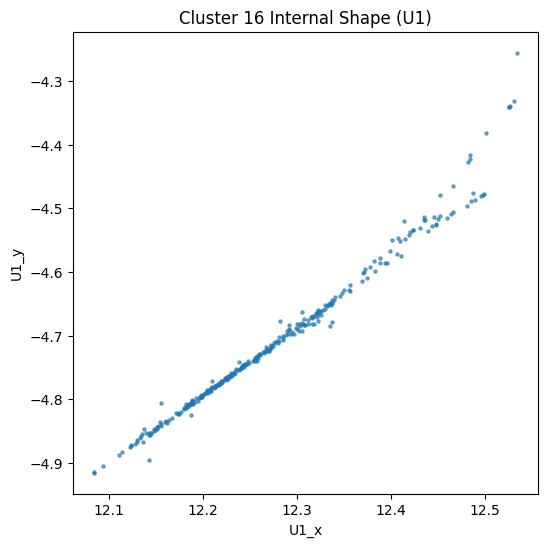

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(viz16["U1_x"], viz16["U1_y"], s=5, alpha=0.6)
plt.title("Cluster 16 Internal Shape (U1)")
plt.xlabel("U1_x")
plt.ylabel("U1_y")
plt.show()


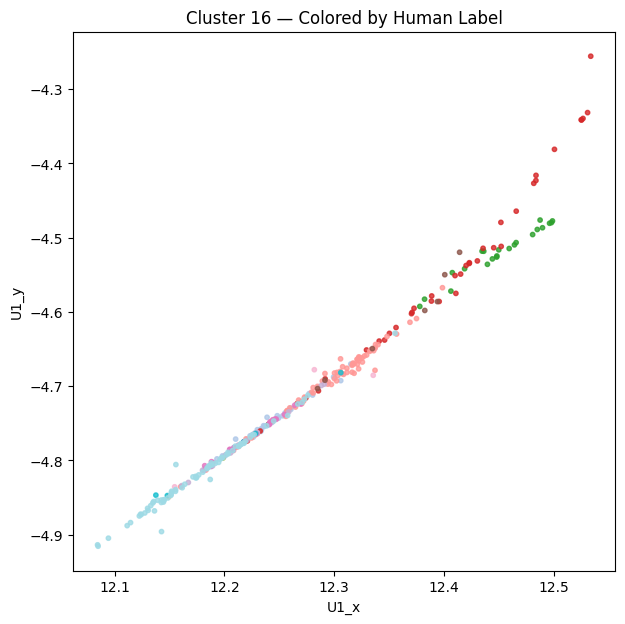

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# scatter with color by true_label
plt.scatter(
    viz16["U1_x"],
    viz16["U1_y"],
    c=pd.factorize(viz16["true_label"])[0],  # convert labels to ints
    cmap="tab20",
    s=10,
    alpha=0.8
)

plt.title("Cluster 16 — Colored by Human Label")
plt.xlabel("U1_x")
plt.ylabel("U1_y")
plt.show()


In [28]:
# Let's inspect labels for the lower-left 1/3 of the curve
lower_segment = viz16.nsmallest(int(len(viz16)/3), "U1_x")
lower_segment["true_label"].value_counts()


true_label
Whistle                65
No_Glitch              10
Power_Line              7
Air_Compressor          7
Low_Frequency_Lines     4
Wandering_Line          2
Helix                   1
Scattered_Light         1
Violin_Mode             1
Scratchy                1
1080Lines               1
Name: count, dtype: int64

In [29]:
# Middle 1/3
middle_segment = viz16.iloc[int(len(viz16)/3):int(2*len(viz16)/3)]
middle_segment["true_label"].value_counts()


true_label
Low_Frequency_Lines    73
No_Glitch              17
None_of_the_Above       8
Power_Line              3
Name: count, dtype: int64

In [30]:
# Upper-right 1/3
upper_segment = viz16.nlargest(int(len(viz16)/3), "U1_x")
upper_segment["true_label"].value_counts()


true_label
Low_Frequency_Lines    37
Low_Frequency_Burst    32
Light_Modulation       22
None_of_the_Above       5
Whistle                 1
Scattered_Light         1
Air_Compressor          1
Wandering_Line          1
Name: count, dtype: int64

In [31]:
# Sort Cluster 16 along the UMAP curve (U1_x)
cluster16_ordered = cluster16_df.sort_values("U1_x").reset_index(drop=True)

n = len(cluster16_ordered)
one_third = n // 3

# Assign segments: lower, middle, upper
cluster16_ordered["segment"] = "middle"
cluster16_ordered.loc[:one_third-1, "segment"] = "lower"
cluster16_ordered.loc[2*one_third:, "segment"] = "upper"

cluster16_ordered[["U1_x", "U1_y", "true_label", "segment"]].head(10)


,U1_x,U1_y,true_label,segment
0,12.084447,-4.913657,Whistle,lower
1,12.084928,-4.915535,Whistle,lower
2,12.094331,-4.904709,Whistle,lower
3,12.111413,-4.887815,Whistle,lower
4,12.114489,-4.883724,Whistle,lower
5,12.122509,-4.874808,Whistle,lower
6,12.123666,-4.872351,Whistle,lower
7,12.124202,-4.872976,Whistle,lower
8,12.127510,-4.870752,Whistle,lower
9,12.129995,-4.864497,Whistle,lower


In [32]:
cluster16_ordered["segment"].value_counts()


segment
upper     102
lower     100
middle    100
Name: count, dtype: int64

In [33]:
def select_evenly(df, n=6):
    idxs = np.linspace(0, len(df)-1, n, dtype=int)
    return df.iloc[idxs]

lower_samples  = select_evenly(cluster16_ordered[cluster16_ordered["segment"]=="lower"])
middle_samples = select_evenly(cluster16_ordered[cluster16_ordered["segment"]=="middle"])
upper_samples  = select_evenly(cluster16_ordered[cluster16_ordered["segment"]=="upper"])

lower_samples[["path","true_label"]], middle_samples[["path","true_label"]], upper_samples[["path","true_label"]]


(                                                 path true_label
 0   C:\Users\mygam\Documents\gravityspy-project\da...    Whistle
 19  C:\Users\mygam\Documents\gravityspy-project\da...    Whistle
 39  C:\Users\mygam\Documents\gravityspy-project\da...    Whistle
 59  C:\Users\mygam\Documents\gravityspy-project\da...    Whistle
 79  C:\Users\mygam\Documents\gravityspy-project\da...    Whistle
 99  C:\Users\mygam\Documents\gravityspy-project\da...  1080Lines,
                                                   path           true_label
 100  C:\Users\mygam\Documents\gravityspy-project\da...              Whistle
 119  C:\Users\mygam\Documents\gravityspy-project\da...       Wandering_Line
 139  C:\Users\mygam\Documents\gravityspy-project\da...       Air_Compressor
 159  C:\Users\mygam\Documents\gravityspy-project\da...           Power_Line
 179  C:\Users\mygam\Documents\gravityspy-project\da...  Low_Frequency_Lines
 199  C:\Users\mygam\Documents\gravityspy-project\da...  Low_Frequency_Line

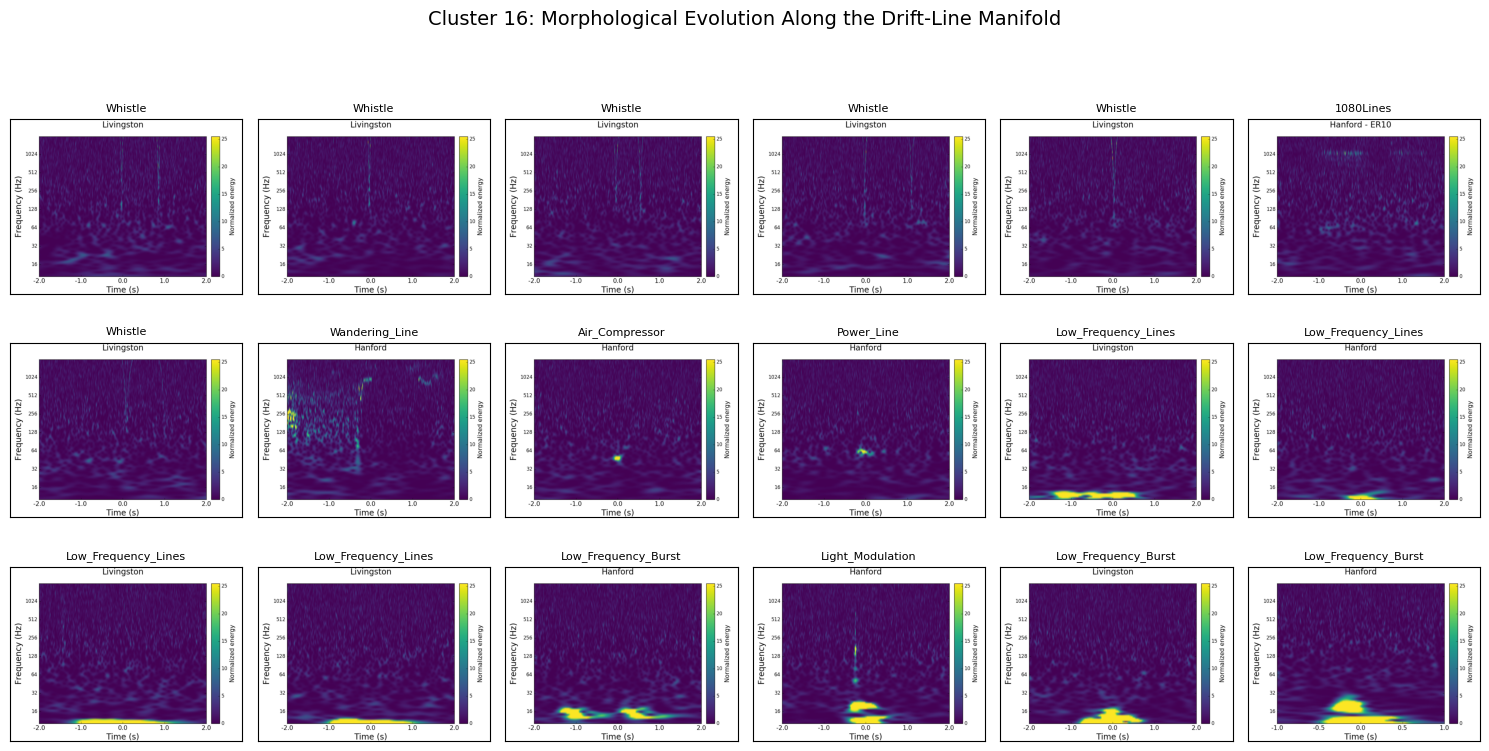

In [34]:
import matplotlib.pyplot as plt
from PIL import Image

# Combine the three sample sets into one list of rows
rows = [lower_samples, middle_samples, upper_samples]

fig, axes = plt.subplots(nrows=3, ncols=len(lower_samples), figsize=(15, 8))

for row_idx, segment_df in enumerate(rows):
    for col_idx, (_, row) in enumerate(segment_df.iterrows()):
        ax = axes[row_idx, col_idx]

        # Load the image
        img = Image.open(row["path"])

        # Show image
        ax.imshow(img, cmap="gray")
        ax.set_title(row["true_label"], fontsize=8)

        # Remove axes
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Cluster 16: Morphological Evolution Along the Drift-Line Manifold", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()


In [35]:
core_labels = [
    "Whistle",
    "Low_Frequency_Lines",
    "Low_Frequency_Burst",
    "Light_Modulation",
    "Wandering_Line",
]

cluster16_ordered["is_core"] = cluster16_ordered["true_label"].isin(core_labels)

cluster16_ordered[["true_label", "segment", "is_core"]].head(10)


,true_label,segment,is_core
0,Whistle,lower,True
1,Whistle,lower,True
2,Whistle,lower,True
3,Whistle,lower,True
4,Whistle,lower,True
5,Whistle,lower,True
6,Whistle,lower,True
7,Whistle,lower,True
8,Whistle,lower,True
9,Whistle,lower,True


In [36]:
total = len(cluster16_ordered)
core = cluster16_ordered["is_core"].sum()
inconsistent = total - core

print("Total samples:", total)
print("Core-label samples:", core)
print("Inconsistent-label samples:", inconsistent)
print("Inconsistent label rate:", inconsistent / total)


Total samples: 302
Core-label samples: 216
Inconsistent-label samples: 86
Inconsistent label rate: 0.2847682119205298


In [37]:
segment_summary = (
    cluster16_ordered
    .groupby("segment")["is_core"]
    .agg(["count", "sum"])
    .rename(columns={"count": "total", "sum": "core"})
)

segment_summary["inconsistent"] = segment_summary["total"] - segment_summary["core"]
segment_summary["inconsistent_rate"] = segment_summary["inconsistent"] / segment_summary["total"]

segment_summary


,total,core,inconsistent,inconsistent_rate
segment,,,,
lower,100,71,29,0.290000
middle,100,51,49,0.490000
upper,102,94,8,0.078431


In [38]:
label_audit = (
    cluster16_ordered
    .groupby("true_label")["is_core"]
    .agg(["count", "sum"])
    .rename(columns={"count": "total", "sum": "core"})
)

label_audit["inconsistent"] = label_audit["total"] - label_audit["core"]
label_audit["inconsistent_rate"] = label_audit["inconsistent"] / label_audit["total"]

label_audit.sort_values("inconsistent_rate", ascending=False)


,total,core,inconsistent,inconsistent_rate
true_label,,,,
1080Lines,1,0,1,1.0
Air_Compressor,37,0,37,1.0
Helix,1,0,1,1.0
Power_Line,17,0,17,1.0
None_of_the_Above,8,0,8,1.0
No_Glitch,17,0,17,1.0
Scratchy,1,0,1,1.0
Violin_Mode,1,0,1,1.0
Scattered_Light,3,0,3,1.0


In [39]:
segment_to_label = {
    "lower": "Whistle",
    "middle": "Low_Frequency_Lines",
    "upper": "Low_Frequency_Burst",
}

cluster16_ordered["proposed_label"] = cluster16_ordered["segment"].map(segment_to_label)

cluster16_ordered[["true_label", "segment", "proposed_label"]].head(10)


,true_label,segment,proposed_label
0,Whistle,lower,Whistle
1,Whistle,lower,Whistle
2,Whistle,lower,Whistle
3,Whistle,lower,Whistle
4,Whistle,lower,Whistle
5,Whistle,lower,Whistle
6,Whistle,lower,Whistle
7,Whistle,lower,Whistle
8,Whistle,lower,Whistle
9,Whistle,lower,Whistle


In [40]:
import os

# Extract sample_id from path
cluster16_ordered["sample_id"] = cluster16_ordered["path"].apply(lambda p: os.path.basename(p))

# Create justifications
def justify(row):
    if row["segment"] == "lower":
        return "High-frequency morphology (Whistle region)"
    elif row["segment"] == "middle":
        return "Mid-frequency drift-line morphology"
    else:  # upper
        return "Low-frequency broadened drift / burst morphology"

cluster16_ordered["justification"] = cluster16_ordered.apply(justify, axis=1)

cluster16_ordered[["sample_id", "true_label", "segment", "proposed_label", "justification"]].head(10)


,sample_id,true_label,segment,proposed_label,justification
0,L1_eZzhGjK5ck_spectrogram_4.0.png,Whistle,lower,Whistle,High-frequency morphology (Whistle region)
1,L1_yZPB2Lkecd_spectrogram_4.0.png,Whistle,lower,Whistle,High-frequency morphology (Whistle region)
2,L1_t0VTnAMWql_spectrogram_4.0.png,Whistle,lower,Whistle,High-frequency morphology (Whistle region)
3,L1_hDKn8tIhsb_spectrogram_4.0.png,Whistle,lower,Whistle,High-frequency morphology (Whistle region)
4,L1_xmLt4mkEr8_spectrogram_4.0.png,Whistle,lower,Whistle,High-frequency morphology (Whistle region)
5,L1_QCrhmM41mc_spectrogram_4.0.png,Whistle,lower,Whistle,High-frequency morphology (Whistle region)
6,L1_7hKZ468uHL_spectrogram_4.0.png,Whistle,lower,Whistle,High-frequency morphology (Whistle region)
7,L1_zuftnZAv2p_spectrogram_4.0.png,Whistle,lower,Whistle,High-frequency morphology (Whistle region)
8,L1_4f5Zbu8tyv_spectrogram_4.0.png,Whistle,lower,Whistle,High-frequency morphology (Whistle region)
9,L1_VIGcOITNeO_spectrogram_4.0.png,Whistle,lower,Whistle,High-frequency morphology (Whistle region)


In [41]:
# Filter inconsistent samples only
corrections = cluster16_ordered[cluster16_ordered["is_core"] == False]

# Sort by segment then human label
corrections = corrections.sort_values(["segment", "true_label"])

# Select only the columns we need
corrections_table = corrections[[
    "sample_id",
    "true_label",
    "segment",
    "proposed_label",
    "justification"
]]

corrections_table.head(20)


,sample_id,true_label,segment,proposed_label,justification
99,H1_CHUZJp0lLA_spectrogram_4.0.png,1080Lines,lower,Whistle,High-frequency morphology (Whistle region)
48,H1_6dm2tquJFb_spectrogram_4.0.png,Air_Compressor,lower,Whistle,High-frequency morphology (Whistle region)
66,H1_RiTNwU1wPp_spectrogram_4.0.png,Air_Compressor,lower,Whistle,High-frequency morphology (Whistle region)
71,H1_z69vZWN8U5_spectrogram_4.0.png,Air_Compressor,lower,Whistle,High-frequency morphology (Whistle region)
74,H1_aHmlPNowBS_spectrogram_4.0.png,Air_Compressor,lower,Whistle,High-frequency morphology (Whistle region)
75,H1_DJh3ZCLfVC_spectrogram_4.0.png,Air_Compressor,lower,Whistle,High-frequency morphology (Whistle region)
86,H1_pruBtY7y0L_spectrogram_4.0.png,Air_Compressor,lower,Whistle,High-frequency morphology (Whistle region)
89,H1_3EBqetoLvI_spectrogram_4.0.png,Air_Compressor,lower,Whistle,High-frequency morphology (Whistle region)
25,H1_NOsYE0219V_spectrogram_4.0.png,Helix,lower,Whistle,High-frequency morphology (Whistle region)
35,L1_uDqC1GnX72_spectrogram_4.0.png,No_Glitch,lower,Whistle,High-frequency morphology (Whistle region)


In [42]:
from pathlib import Path
import os

# This should be run from the `notebooks/` folder
print("CWD:", os.getcwd())

base_dir = Path("..").resolve()
out_dir = base_dir / "findings" / "cluster_16_deep_dive"
out_dir.mkdir(parents=True, exist_ok=True)

print("Saving outputs to:", out_dir)


CWD: c:\Users\mygam\Documents\gravityspy-glitch-explorer\notebooks
Saving outputs to: C:\Users\mygam\Documents\gravityspy-glitch-explorer\findings\cluster_16_deep_dive


In [43]:
import pandas as pd

# 1) Rebuild 'is_core' if needed (safe to re-run)
def is_core_label(row):
    if row["segment"] == "lower":
        return row["true_label"] == "Whistle"
    elif row["segment"] == "middle":
        return row["true_label"] == "Low_Frequency_Lines"
    else:  # upper
        return row["true_label"] in ["Low_Frequency_Burst", "Light_Modulation"]

cluster16_ordered["is_core"] = cluster16_ordered.apply(is_core_label, axis=1)

# 2) Segment→proposed label mapping (segment_to_label still same as before)
segment_to_label = {
    "lower": "Whistle",
    "middle": "Low_Frequency_Lines",
    "upper": "Low_Frequency_Burst",
}
cluster16_ordered["proposed_label"] = cluster16_ordered["segment"].map(segment_to_label)

# 3) Create sample_id + justification again (safe to re-run)
def justify(row):
    if row["segment"] == "lower":
        return "High-frequency morphology (Whistle region)"
    elif row["segment"] == "middle":
        return "Mid-frequency drift-line morphology"
    else:
        return "Low-frequency broadened drift / burst morphology"

cluster16_ordered["sample_id"] = cluster16_ordered["path"].apply(os.path.basename)
cluster16_ordered["justification"] = cluster16_ordered.apply(justify, axis=1)

# 4) Build corrections_table (only inconsistent samples)
corrections = cluster16_ordered[cluster16_ordered["is_core"] == False]
corrections = corrections.sort_values(["segment", "true_label"])

corrections_table = corrections[[
    "sample_id",
    "true_label",
    "segment",
    "proposed_label",
    "justification"
]]

# Save to CSV
corr_path = out_dir / "correction_table.csv"
corrections_table.to_csv(corr_path, index=False)
corr_path, corrections_table.head(5)


(WindowsPath('C:/Users/mygam/Documents/gravityspy-glitch-explorer/findings/cluster_16_deep_dive/correction_table.csv'),
                             sample_id      true_label segment proposed_label  \
 99  H1_CHUZJp0lLA_spectrogram_4.0.png       1080Lines   lower        Whistle   
 48  H1_6dm2tquJFb_spectrogram_4.0.png  Air_Compressor   lower        Whistle   
 66  H1_RiTNwU1wPp_spectrogram_4.0.png  Air_Compressor   lower        Whistle   
 71  H1_z69vZWN8U5_spectrogram_4.0.png  Air_Compressor   lower        Whistle   
 74  H1_aHmlPNowBS_spectrogram_4.0.png  Air_Compressor   lower        Whistle   
 
                                  justification  
 99  High-frequency morphology (Whistle region)  
 48  High-frequency morphology (Whistle region)  
 66  High-frequency morphology (Whistle region)  
 71  High-frequency morphology (Whistle region)  
 74  High-frequency morphology (Whistle region)  )

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure we only use samples from cluster 16 (in case DF has more)
cluster16_df = cluster16_ordered.copy()

# Split by segment
lower_df  = cluster16_df[cluster16_df["segment"] == "lower"]
middle_df = cluster16_df[cluster16_df["segment"] == "middle"]
upper_df  = cluster16_df[cluster16_df["segment"] == "upper"]

def pick_samples(df, n=6):
    # pick n evenly-spaced samples along the manifold
    n = min(n, len(df))
    idx = np.linspace(0, len(df) - 1, n, dtype=int)
    return df.iloc[idx]

lower_samples  = pick_samples(lower_df, 6)
middle_samples = pick_samples(middle_df, 6)
upper_samples  = pick_samples(upper_df, 6)

rows = [lower_samples, middle_samples, upper_samples]
row_titles = ["Lower segment (Whistle end)",
              "Middle segment (Line region)",
              "Upper segment (Burst end)"]

n_cols = max(len(r) for r in rows)

fig, axes = plt.subplots(
    nrows=3,
    ncols=n_cols,
    figsize=(4 * n_cols, 3 * 3),
    squeeze=False
)

for r, (seg_df, seg_title) in enumerate(zip(rows, row_titles)):
    for c in range(n_cols):
        ax = axes[r, c]
        if c < len(seg_df):
            row = seg_df.iloc[c]
            img = plt.imread(row["path"])
            ax.imshow(img, aspect="auto", origin="lower")
            ax.set_title(row["true_label"], fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
    # Optional: label the rows on the left
    axes[r, 0].set_ylabel(seg_title, fontsize=9)

fig.suptitle(
    "Cluster 16: Morphological Evolution Along the Drift-Line Manifold",
    fontsize=14
)
plt.tight_layout(rect=[0, 0, 1, 0.95])

atlas_path = out_dir / "atlas_3row.png"
fig.savefig(atlas_path, dpi=150)
plt.close(fig)

atlas_path


WindowsPath('C:/Users/mygam/Documents/gravityspy-glitch-explorer/findings/cluster_16_deep_dive/atlas_3row.png')

In [45]:
import json

total = int(len(cluster16_df))
core = int((cluster16_df["is_core"] == True).sum())
inconsistent = int((cluster16_df["is_core"] == False).sum())
inconsistent_rate = inconsistent / total

segment_counts = {}
for seg, g in cluster16_df.groupby("segment"):
    seg_total = int(len(g))
    seg_core = int((g["is_core"] == True).sum())
    seg_inconsistent = seg_total - seg_core
    segment_counts[seg] = {
        "total": seg_total,
        "core": seg_core,
        "inconsistent": seg_inconsistent,
        "inconsistent_rate": seg_inconsistent / seg_total
    }

# dominant labels just for documentation
dominant_labels = (
    cluster16_df["true_label"]
    .value_counts()
    .head(5)
    .index
    .tolist()
)

meta = {
    "cluster_id": 16,
    "total_samples": total,
    "core_samples": core,
    "inconsistent_labels": inconsistent,
    "inconsistent_rate": inconsistent_rate,
    "segment_counts": segment_counts,
    "dominant_labels": dominant_labels
}

meta_path = out_dir / "metadata.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

meta_path, meta


(WindowsPath('C:/Users/mygam/Documents/gravityspy-glitch-explorer/findings/cluster_16_deep_dive/metadata.json'),
 {'cluster_id': 16,
  'total_samples': 302,
  'core_samples': 151,
  'inconsistent_labels': 151,
  'inconsistent_rate': 0.5,
  'segment_counts': {'lower': {'total': 100,
    'core': 65,
    'inconsistent': 35,
    'inconsistent_rate': 0.35},
   'middle': {'total': 100,
    'core': 32,
    'inconsistent': 68,
    'inconsistent_rate': 0.68},
   'upper': {'total': 102,
    'core': 54,
    'inconsistent': 48,
    'inconsistent_rate': 0.47058823529411764}},
  'dominant_labels': ['Whistle',
   'Low_Frequency_Lines',
   'Low_Frequency_Burst',
   'Air_Compressor',
   'Light_Modulation']})